In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
import importlib
import matplotlib.pyplot as plt
importlib.reload(plt)


<module 'matplotlib.pyplot' from 'c:\\Users\\admin\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [59]:
np.random.seed(42)  

cgpa = np.round(np.random.uniform(5.5, 9.8, 100), 2)

package = np.round(2.5 * cgpa +np.random.normal(0.2,1.5,100) , 2)

# Ensure package is not negative
package = np.clip(package, 3, None)

In [60]:
df = pd.DataFrame({
    'CGPA': cgpa,
    'Package_LPA': package
})

df

,CGPA,Package_LPA
0,7.11,18.11
1,9.59,23.73
2,8.65,21.96
3,8.07,17.39
4,6.17,15.30
...,...,...
95,7.62,18.03
96,7.75,19.46
97,7.34,19.06
98,5.61,14.64


Text(0, 0.5, 'Package')

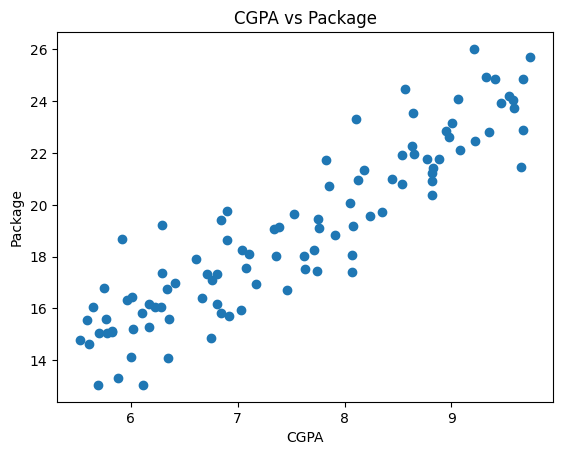

In [61]:
plt.scatter(df['CGPA'],df['Package_LPA'])
plt.title('CGPA vs Package')
plt.xlabel('CGPA')
plt.ylabel('Package')

In [62]:
X = df.iloc[:, 0:1]
X


,CGPA
0,7.11
1,9.59
2,8.65
3,8.07
4,6.17
...,...
95,7.62
96,7.75
97,7.34
98,5.61


In [63]:
y=df.iloc[:,1:2]
y

,Package_LPA
0,18.11
1,23.73
2,21.96
3,17.39
4,15.30
...,...
95,18.03
96,19.46
97,19.06
98,14.64


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [65]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [66]:
lr=LinearRegression()

In [67]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
X_test

,CGPA
83,5.77
30,8.11
56,5.88
24,7.46
16,6.81
23,7.08
2,8.65
27,7.71
28,8.05
13,6.41


In [69]:
X_test.shape

(20, 1)

In [70]:
X_test.iloc[[1]]

,CGPA
30,8.11


In [71]:
y_test.iloc[[1]]

,Package_LPA
30,23.3


In [73]:
lr.predict(X_test.iloc[[1]])

array([[20.45509294]])

In [74]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R2 Score: 0.7594369501159515
MAE: 0.9575126039056056


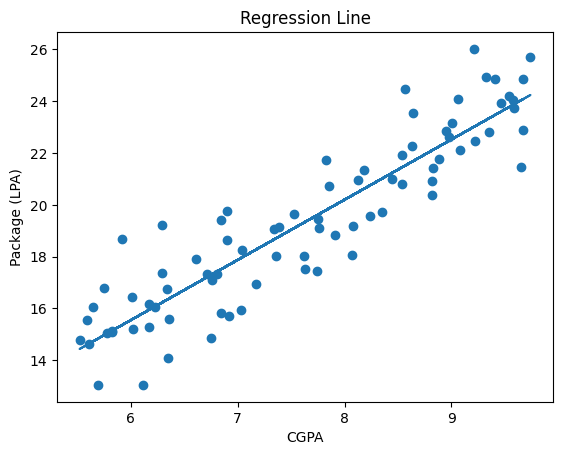

In [75]:
plt.scatter(X_train, y_train)
plt.plot(X_train, lr.predict(X_train))
plt.xlabel('CGPA')
plt.ylabel('Package (LPA)')
plt.title('Regression Line')
plt.show()


In [76]:
m=lr.coef_
m

array([[2.32354703]])

In [77]:
b=lr.intercept_
b

array([1.61112656])

In [78]:
def fun(x):
    return 2.32 * x + 1.41

In [79]:
fun(8.11)

20.225199999999997